# PowerLift-AI-X — Exploratory Data Analysis

## Objective

This notebook performs a structured exploratory analysis of the **final resolved PowerLift-AI-X dataset**.

### Input dataset

`data/final/exports/powerlift_ai_x_final_dataset.xlsx`

The workbook contains the resolved competition-result records exported from the canonical dataset.

### EDA goals

- Understand dataset size and structure
- Profile identity-resolution fields
- Analyze competitions, years, divisions, weight classes, and equipment
- Explore bodyweight and powerlifting performance
- Inspect missing values and zero-valued attempts
- Check duplicate and consistency signals
- Examine athlete-level participation and performance
- Identify distributions, correlations, and potential outliers
- Assess readiness for feature engineering and ML

> **Important:** EDA is descriptive. This notebook does not modify the source dataset or silently correct values.


## 1. Imports and Configuration

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

DATA_CANDIDATES = [Path("data/final/exports/powerlift_ai_x_final_dataset.xlsx"), Path("../data/final/exports/powerlift_ai_x_final_dataset.xlsx"), Path("/mnt/data/powerlift_ai_x_final_dataset.xlsx")]
DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None: raise FileNotFoundError("powerlift_ai_x_final_dataset.xlsx not found")

ATTEMPT_COLUMNS = ["squat_1","squat_2","squat_3","bench_1","bench_2","bench_3","deadlift_1","deadlift_2","deadlift_3"]
BEST_COLUMNS = ["best_squat","best_bench","best_deadlift"]
LIFT_COLUMNS = ["bodyweight", *ATTEMPT_COLUMNS, *BEST_COLUMNS, "total"]


## 2. Load the Final Dataset

The Excel workbook is loaded as the EDA source. No transformations are written back to the workbook.

In [2]:
df = pd.read_excel(DATA_PATH)

print("Shape:", df.shape)
display(df.head())


Shape: (9874, 26)


,athlete_id,bench_1,bench_2,bench_3,best_bench,best_deadlift,best_squat,bodyweight,competition,date_of_birth,deadlift_1,deadlift_2,deadlift_3,division,equipment,lot,place,squat_1,squat_2,squat_3,team,total,weight_class,year,resolved_athlete_id,identity_confidence
0,ATH-3329e53259abce06,110.0,120.0,120.0,120.0,232.5,200.0,58.80,National Classic Powerlifting Championship 2019,13-08-1991,200.0,222.5,232.5,Open,CLASSIC,62.0,1.0,170.0,190.0,200.0,PUD,552.5,59,2019,ATH-3329e53259abce06,UNIQUE_CANDIDATE
1,ATH-3f4818d49460c4d4,125.0,132.5,140.0,140.0,217.5,190.0,58.95,National Classic Powerlifting Championship 2019,01-10-1993,207.5,217.5,225.0,Open,CLASSIC,61.0,2.0,180.0,190.0,202.5,MAH,547.5,59,2019,ATH-3f4818d49460c4d4,UNIQUE_CANDIDATE
2,ATH-4c9fc72c7abc16d2,105.0,115.0,122.5,122.5,200.0,185.0,56.60,National Classic Powerlifting Championship 2019,10-11-1994,185.0,200.0,210.0,Open,CLASSIC,63.0,3.0,170.0,177.5,185.0,T.N,507.5,59,2019,ATH-4c9fc72c7abc16d2,UNIQUE_CANDIDATE
3,ATH-c3ef71ff4b36607e,80.0,85.0,85.0,80.0,217.5,162.5,58.65,National Classic Powerlifting Championship 2019,31-12-1991,207.5,217.5,225.0,Open,CLASSIC,65.0,4.0,152.5,162.5,167.5,ASA,460.0,59,2019,ATH-c3ef71ff4b36607e,UNIQUE_CANDIDATE
4,ATH-33edebc06d4b41ea,85.0,90.0,92.5,92.5,190.0,175.0,58.30,National Classic Powerlifting Championship 2019,11-08-1996,190.0,190.0,200.0,Open,CLASSIC,70.0,5.0,165.0,175.0,180.0,ODI,457.5,59,2019,ATH-33edebc06d4b41ea,UNIQUE_CANDIDATE


## 3. Dataset Schema and Data Types

In [3]:
schema = pd.DataFrame({
    "field": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "non_null": [df[c].notna().sum() for c in df.columns],
    "missing": [df[c].isna().sum() for c in df.columns],
    "unique": [df[c].nunique(dropna=True) for c in df.columns],
})
display(schema)


,field,dtype,non_null,missing,unique
0,athlete_id,object,9874,0,5462
1,bench_1,float64,9743,131,111
2,bench_2,float64,9528,346,132
3,bench_3,float64,9216,658,162
4,best_bench,float64,9745,129,144
5,best_deadlift,float64,9688,186,174
6,best_squat,float64,9856,18,200
7,bodyweight,float64,9874,0,2392
8,competition,object,9874,0,74
9,date_of_birth,object,7690,2184,3367


## 4. Dataset Overview

This section establishes the basic scale of the dataset and its major entities.

In [4]:
overview = pd.Series({
    "records": len(df),
    "columns": len(df.columns),
    "candidate_athletes": df["athlete_id"].nunique(),
    "resolved_athletes": df["resolved_athlete_id"].nunique(),
    "competitions": df["competition"].nunique(),
    "years": df["year"].nunique(),
    "min_year": df["year"].min(),
    "max_year": df["year"].max(),
})
display(overview.to_frame("value"))


,value
records,9874
columns,26
candidate_athletes,5462
resolved_athletes,5601
competitions,74
years,10
min_year,2017
max_year,2026


## 5. Identity Resolution Analysis

The final dataset contains both the original candidate identity and the resolved identity. We inspect confidence categories and check that resolved IDs are populated.

In [5]:
identity_summary = (
    df["identity_confidence"]
    .value_counts(dropna=False)
    .rename_axis("identity_confidence")
    .reset_index(name="records")
)
identity_summary["percent"] = (identity_summary["records"] / len(df) * 100).round(2)

print("Missing resolved IDs:", df["resolved_athlete_id"].isna().sum())
display(identity_summary)


Missing resolved IDs: 0


,identity_confidence,records,percent
0,UNIQUE_CANDIDATE,9660,97.83
1,RESOLVED_SPLIT,158,1.60
2,RESOLVED_SAME,56,0.57


## 6. Competition and Year Analysis

In [6]:
year_summary = (
    df["year"].value_counts()
    .sort_index()
    .rename_axis("year")
    .reset_index(name="records")
)
display(year_summary)

competition_summary = (
    df["competition"].value_counts()
    .rename_axis("competition")
    .reset_index(name="records")
)
display(competition_summary.head(20))


,year,records
0,2017,50
1,2018,1707
2,2019,1025
3,2020,207
4,2021,526
5,2022,2014
6,2023,1080
7,2024,1242
8,2025,1080
9,2026,943


,competition,records
0,National Classic Powerlifting Championship 202...,565
1,National Classic Powerlifting Championship 2018,521
2,National Classic Powerlifting Championship 2019,447
3,"National Sub Junior, Junior & Masters Equipped...",311
4,National Sub Junior & Junior Equipped Powerlif...,296
5,National Sub Junior & Junior Classic Powerlift...,262
6,"National Senior, Sub Junior & Junior Equipped ...",257
7,"National Senior, Sub Junior & Junior Classic P...",248
8,National Sub Junior and Junior Classic Powerli...,247
9,National Sub Junior and Junior Classic Powerli...,237


<Figure size 1000x500 with 0 Axes>

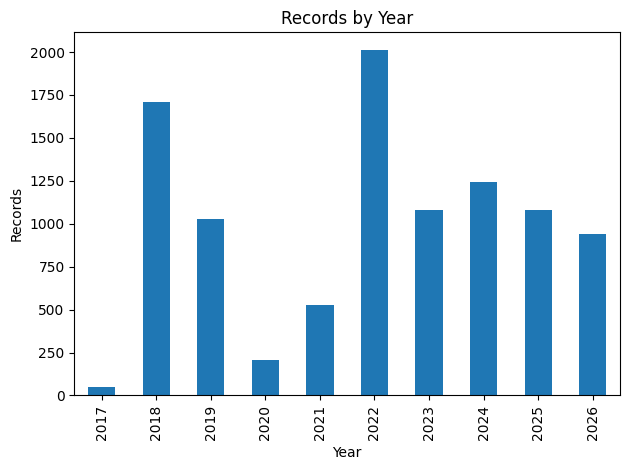

In [7]:
fig = plt.figure(figsize=(10, 5))
year_summary.plot(x="year", y="records", kind="bar", legend=False)
plt.title("Records by Year")
plt.xlabel("Year")
plt.ylabel("Records")
plt.tight_layout()
plt.show()


## 7. Equipment, Division, and Weight Class

In [8]:
for column in ["equipment", "division", "weight_class"]:
    print(f"--- {column.upper()} ---")
    summary = (
        df[column].fillna("<MISSING>")
        .value_counts()
        .rename_axis(column)
        .reset_index(name="records")
    )
    summary["percent"] = (summary["records"] / len(df) * 100).round(2)
    display(summary)


--- EQUIPMENT ---


,equipment,records,percent
0,CLASSIC,4633,46.92
1,EQUIPPED,4291,43.46
2,UNKNOWN,950,9.62


--- DIVISION ---


,division,records,percent
0,Open,2944,29.82
1,Junior,2846,28.82
2,Sub Junior,2118,21.45
3,Master 1,809,8.19
4,Master 2,630,6.38
5,Master 3,394,3.99
6,Master 4,133,1.35


--- WEIGHT_CLASS ---


,weight_class,records,percent
0,83,1533,15.53
1,74,1493,15.12
2,93,1404,14.22
3,66,1315,13.32
4,59,1150,11.65
5,105,1107,11.21
6,120,1008,10.21
7,53,540,5.47
8,120+,324,3.28


## 8. Bodyweight Analysis

,bodyweight_kg
count,9874.000000
mean,81.457573
std,20.769818
min,40.000000
25%,65.240000
50%,79.780000
75%,93.000000
max,220.000000


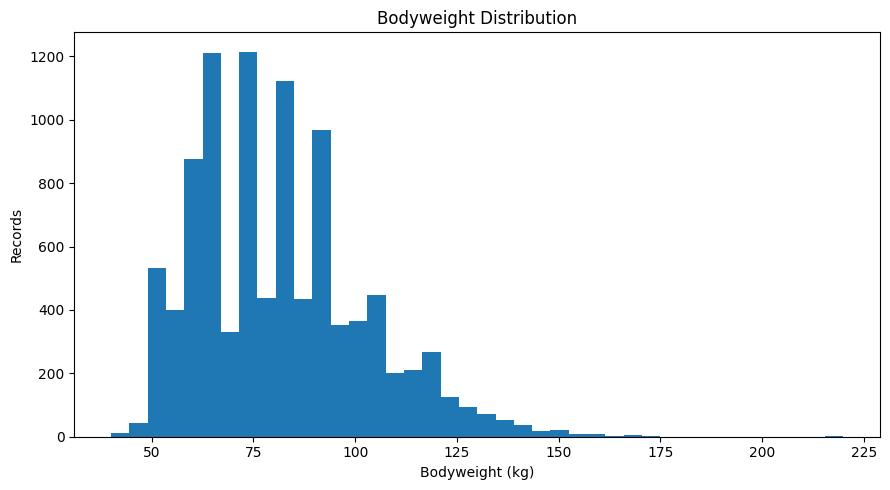

In [9]:
bodyweight = pd.to_numeric(df["bodyweight"], errors="coerce")

display(bodyweight.describe().to_frame("bodyweight_kg"))

fig = plt.figure(figsize=(9, 5))
bodyweight.dropna().plot(kind="hist", bins=40)
plt.title("Bodyweight Distribution")
plt.xlabel("Bodyweight (kg)")
plt.ylabel("Records")
plt.tight_layout()
plt.show()


## 9. Squat, Bench, and Deadlift Analysis

In [10]:
lift_stats = df[LIFT_COLUMNS].apply(pd.to_numeric, errors="coerce").describe().T
display(lift_stats)


,count,mean,std,min,25%,50%,75%,max
bodyweight,9874.0,81.457573,20.769818,40.0,65.24,79.78,93.0,220.0
squat_1,9855.0,184.157291,63.110071,17.0,140.00,180.00,227.5,435.0
squat_2,9761.0,194.354031,66.131017,0.0,150.00,190.00,238.0,1825.0
squat_3,9528.0,201.352907,65.246691,0.0,155.00,197.50,245.0,1325.0
bench_1,9743.0,109.020579,38.384593,20.0,80.00,105.00,135.0,301.0
bench_2,9528.0,116.484068,39.015436,0.0,87.50,112.50,140.0,305.0
bench_3,9216.0,120.767914,39.378890,0.0,92.50,117.50,145.0,315.0
deadlift_1,9687.0,191.643182,48.418021,40.0,160.00,190.00,225.0,336.0
deadlift_2,9376.0,203.978936,48.463049,50.0,170.00,205.00,240.0,355.0
deadlift_3,8994.0,212.778408,60.758791,0.0,180.00,212.50,247.5,3235.0


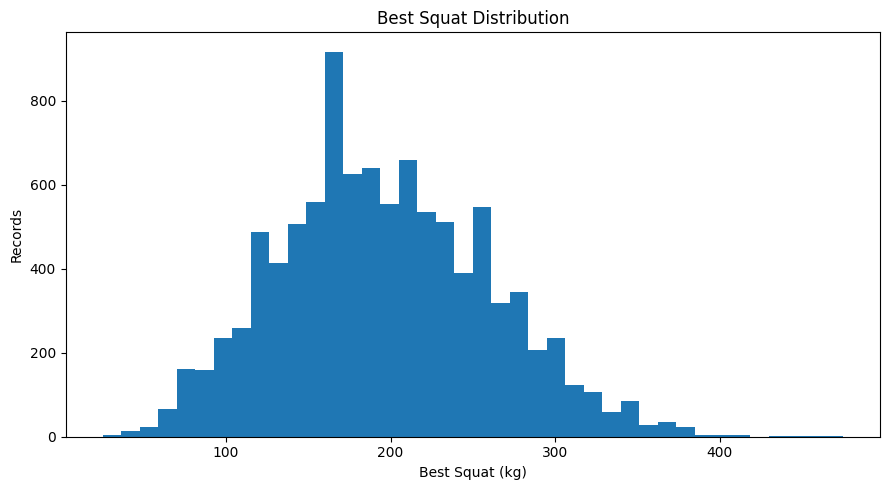

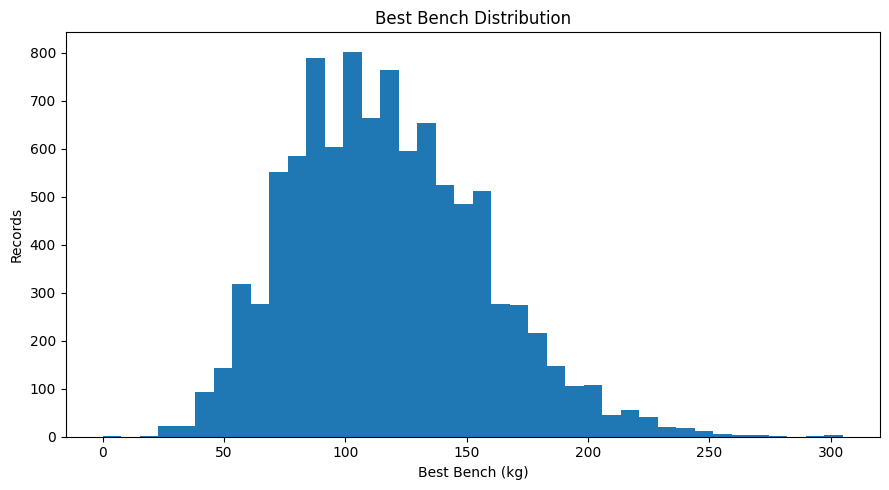

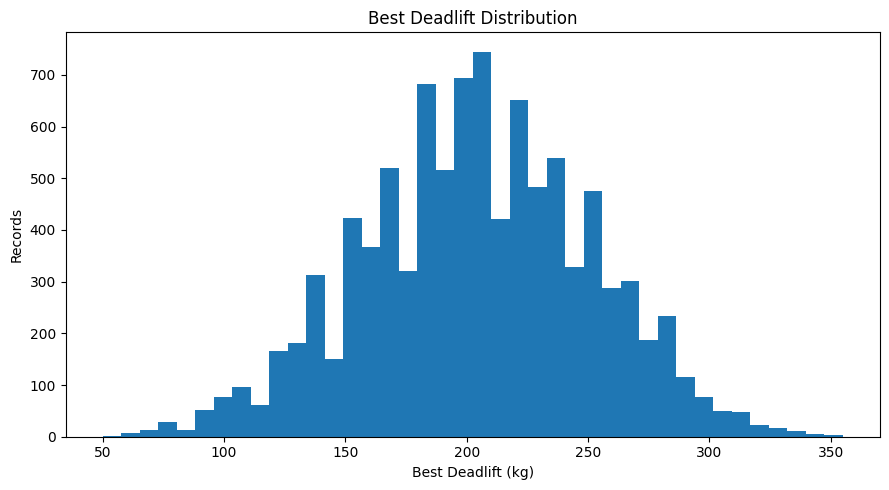

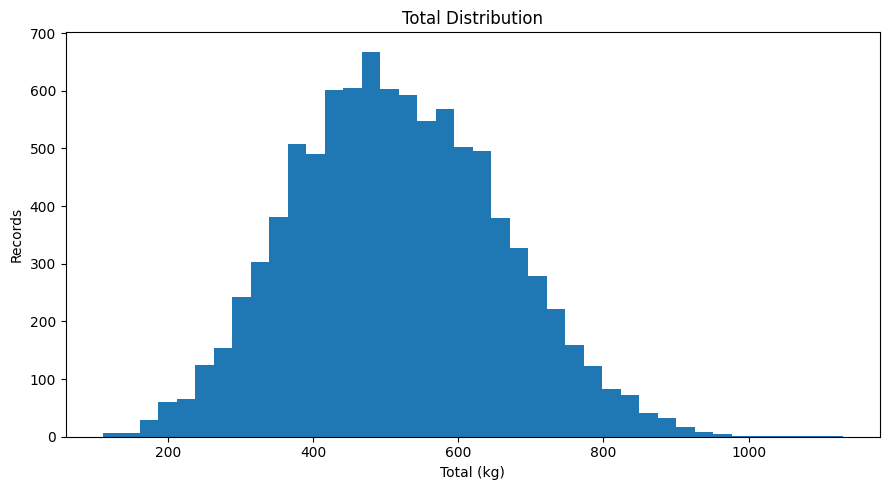

In [11]:
for column, title, xlabel in [
    ("best_squat", "Best Squat Distribution", "Best Squat (kg)"),
    ("best_bench", "Best Bench Distribution", "Best Bench (kg)"),
    ("best_deadlift", "Best Deadlift Distribution", "Best Deadlift (kg)"),
    ("total", "Total Distribution", "Total (kg)"),
]:
    series = pd.to_numeric(df[column], errors="coerce").dropna()
    fig = plt.figure(figsize=(9, 5))
    series.plot(kind="hist", bins=40)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Records")
    plt.tight_layout()
    plt.show()


## 10. Missing-Value Analysis

Missing values are measured field-by-field. They are not imputed during EDA.

In [12]:
missing = pd.DataFrame({
    "field": df.columns,
    "missing_count": [df[c].isna().sum() for c in df.columns],
})
missing["present_count"] = len(df) - missing["missing_count"]
missing["missing_percent"] = (missing["missing_count"] / len(df) * 100).round(2)
missing = missing.sort_values("missing_count", ascending=False)
display(missing)


,field,missing_count,present_count,missing_percent
9,date_of_birth,2184,7690,22.12
15,lot,2184,7690,22.12
20,team,2184,7690,22.12
12,deadlift_3,880,8994,8.91
3,bench_3,658,9216,6.66
16,place,568,9306,5.75
21,total,567,9307,5.74
11,deadlift_2,498,9376,5.04
2,bench_2,346,9528,3.50
19,squat_3,346,9528,3.50


## 11. Zero-Valued Attempts and Incomplete Results

A zero attempt is not automatically treated as missing. We report zeros separately because a zero can carry competition-result meaning.

Earlier dataset auditing identified a small number of zero-valued attempt fields; this section measures them directly in the Excel export.

In [13]:
zero_rows = []
for column in ATTEMPT_COLUMNS:
    values = pd.to_numeric(df[column], errors="coerce")
    zero_rows.append({
        "field": column,
        "zero_count": int(values.eq(0).sum()),
        "missing_count": int(values.isna().sum()),
    })

zero_summary = pd.DataFrame(zero_rows)
display(zero_summary)

print("Total zero-valued attempt cells:", zero_summary["zero_count"].sum())
print("Records with at least one zero attempt:",
      (df[ATTEMPT_COLUMNS].eq(0).any(axis=1)).sum())


,field,zero_count,missing_count
0,squat_1,0,19
1,squat_2,1,113
2,squat_3,1,346
3,bench_1,0,131
4,bench_2,1,346
5,bench_3,3,658
6,deadlift_1,0,187
7,deadlift_2,0,498
8,deadlift_3,2,880


Total zero-valued attempt cells: 8
Records with at least one zero attempt: 7


## 12. Duplicate Checks

We inspect exact duplicate rows and duplicate competition-result identities. This is a diagnostic check only.

In [14]:
print("Exact duplicate rows:", df.duplicated().sum())

identity_key = [
    "resolved_athlete_id",
    "competition",
    "year",
    "division",
    "weight_class",
    "equipment",
]

duplicate_keys = (
    df.groupby(identity_key, dropna=False)
    .size()
    .reset_index(name="records")
)
duplicate_keys = duplicate_keys[duplicate_keys["records"] > 1]

print("Duplicate result identity groups:", len(duplicate_keys))
display(duplicate_keys.head(20))


Exact duplicate rows: 0
Duplicate result identity groups: 0


,resolved_athlete_id,competition,year,division,weight_class,equipment,records


## 13. Total Consistency

For records where all three source-provided best lifts and total are present, verify:

`best_squat + best_bench + best_deadlift = total`

A mismatch is flagged for investigation; values are not changed.

In [15]:
complete = df[BEST_COLUMNS + ["total"]].notna().all(axis=1)

calculated_total = (
    df.loc[complete, "best_squat"]
    + df.loc[complete, "best_bench"]
    + df.loc[complete, "best_deadlift"]
)

total_difference = calculated_total - df.loc[complete, "total"]

print("Rows with all best lifts + total:", complete.sum())
print("Total mismatches (>0.01 kg):", (total_difference.abs() > 0.01).sum())
display(
    pd.DataFrame({
        "calculated_total": calculated_total,
        "source_total": df.loc[complete, "total"],
        "difference": total_difference,
    }).loc[lambda x: x["difference"].abs() > 0.01].head(20)
)


Rows with all best lifts + total: 9306
Total mismatches (>0.01 kg): 0


,calculated_total,source_total,difference


## 14. Athlete-Level Analysis

This section looks at participation history and maximum observed performance per resolved athlete.

In [16]:
athlete_summary = (
    df.groupby("resolved_athlete_id", dropna=False)
    .agg(
        records=("resolved_athlete_id", "size"),
        competitions=("competition", "nunique"),
        first_year=("year", "min"),
        last_year=("year", "max"),
        best_squat=("best_squat", "max"),
        best_bench=("best_bench", "max"),
        best_deadlift=("best_deadlift", "max"),
        best_total=("total", "max"),
        mean_bodyweight=("bodyweight", "mean"),
    )
    .reset_index()
)

athlete_summary["career_span_years"] = (
    athlete_summary["last_year"] - athlete_summary["first_year"]
)

display(athlete_summary.sort_values(
    ["competitions", "records"], ascending=False
).head(25))


,resolved_athlete_id,records,competitions,first_year,last_year,best_squat,best_bench,best_deadlift,best_total,mean_bodyweight,career_span_years
1403,ATH-40b13f7b44aaa235,19,19,2022,2026,315.0,150.0,260.0,717.5,64.818421,4
2451,ATH-72eca94603e17a80,18,18,2018,2025,312.5,177.5,290.0,772.5,80.985556,7
285,ATH-0c9fe4ff11247322,17,17,2018,2026,332.5,175.0,305.0,802.5,86.958824,8
2164,ATH-65731148418b519c,14,14,2018,2024,315.0,182.5,262.5,750.0,74.824286,6
1086,ATH-3111e279395d8df7,13,13,2018,2024,297.5,175.0,285.0,735.0,80.259231,6
2400,ATH-703a057527049e5d,13,13,2018,2026,240.0,165.0,260.0,630.0,81.816154,8
3342,ATH-9cfb8f0f5899d6aa,13,13,2022,2026,280.0,165.0,252.5,692.5,91.520000,4
4155,ATH-c5015e6fbd52ffbf,13,13,2018,2024,362.5,240.0,322.5,915.0,131.503077,6
40,ATH-020a96ba860868e6,12,12,2018,2025,240.0,127.5,237.5,605.0,54.941667,7
2405,ATH-7063cf1242a07ff4,12,12,2019,2025,290.0,185.0,260.0,727.5,73.325833,6


## 15. Correlation Analysis

Correlation is descriptive here. It does not imply causation and does not represent the final ML feature set.

,bodyweight,best_squat,best_bench,best_deadlift,total
bodyweight,1.000,0.507,0.502,0.420,0.499
best_squat,0.507,1.000,0.881,0.874,0.975
best_bench,0.502,0.881,1.000,0.804,0.932
best_deadlift,0.420,0.874,0.804,1.000,0.940
total,0.499,0.975,0.932,0.940,1.000


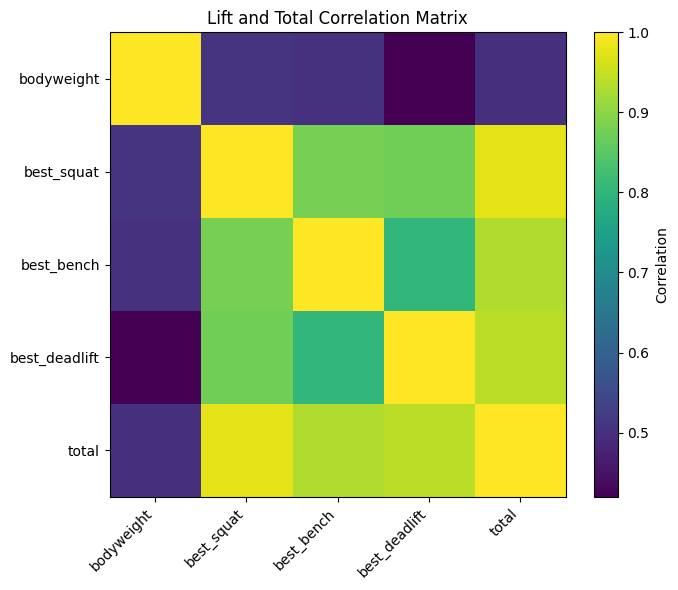

In [17]:
corr_columns = [
    "bodyweight",
    "best_squat",
    "best_bench",
    "best_deadlift",
    "total",
]

correlations = df[corr_columns].apply(pd.to_numeric, errors="coerce").corr()
display(correlations.round(3))

fig = plt.figure(figsize=(7, 6))
plt.imshow(correlations, aspect="auto")
plt.xticks(range(len(corr_columns)), corr_columns, rotation=45, ha="right")
plt.yticks(range(len(corr_columns)), corr_columns)
plt.colorbar(label="Correlation")
plt.title("Lift and Total Correlation Matrix")
plt.tight_layout()
plt.show()


## 16. Outlier Screening

Outlier screening uses the IQR rule as a **flagging mechanism**, not as proof that a record is wrong. Elite powerlifting naturally contains extreme but valid performances.

The results should be reviewed against source records before any correction.

In [18]:
def iqr_flags(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return s.lt(lower) | s.gt(upper)

outlier_summary = []
for column in ["bodyweight", *BEST_COLUMNS, "total"]:
    flags = iqr_flags(df[column])
    outlier_summary.append({
        "field": column,
        "iqr_outlier_count": int(flags.sum()),
        "iqr_outlier_percent": round(flags.mean() * 100, 2),
    })

outlier_summary = pd.DataFrame(outlier_summary)
display(outlier_summary)


,field,iqr_outlier_count,iqr_outlier_percent
0,bodyweight,153,1.55
1,best_squat,33,0.33
2,best_bench,115,1.16
3,best_deadlift,14,0.14
4,total,29,0.29


## 17. ML-Readiness Checks

This is a preliminary readiness assessment, not model training.

### Questions

- Are required identity fields populated?
- Are numeric values parseable?
- Are totals internally consistent?
- Are duplicate result groups present?
- Are missing values concentrated in optional metadata?
- Are there known zero-attempt records requiring domain-aware handling?

The next stage after EDA should be **data-quality decisions and feature engineering**, not immediate model training.

In [19]:
readiness = {
    "records": len(df),
    "missing_resolved_ids": int(df["resolved_athlete_id"].isna().sum()),
    "missing_required_competition": int(df["competition"].isna().sum()),
    "missing_required_year": int(df["year"].isna().sum()),
    "missing_required_division": int(df["division"].isna().sum()),
    "missing_required_weight_class": int(df["weight_class"].isna().sum()),
    "missing_required_equipment": int(df["equipment"].isna().sum()),
    "exact_duplicate_rows": int(df.duplicated().sum()),
    "records_with_zero_attempt": int(df[ATTEMPT_COLUMNS].eq(0).any(axis=1).sum()),
}
display(pd.Series(readiness, name="value").to_frame())


,value
records,9874
missing_resolved_ids,0
missing_required_competition,0
missing_required_year,0
missing_required_division,0
missing_required_weight_class,0
missing_required_equipment,0
exact_duplicate_rows,0
records_with_zero_attempt,7


# 18. Evidence-Based EDA Findings

The following section summarizes the checks above from the actual workbook.


In [20]:
records=len(df)
athletes=df["resolved_athlete_id"].nunique()
competitions=df["competition"].nunique()
zero_records=int(df[ATTEMPT_COLUMNS].eq(0).any(axis=1).sum())
missing_total=int(df["total"].isna().sum())
exact_dupes=int(df.duplicated().sum())
complete=df[BEST_COLUMNS+["total"]].notna().all(axis=1)
calc=df.loc[complete,"best_squat"]+df.loc[complete,"best_bench"]+df.loc[complete,"best_deadlift"]
mismatch=int((calc-df.loc[complete,"total"]).abs().gt(0.01).sum())
print(f"Records: {records:,}")
print(f"Resolved athletes: {athletes:,}")
print(f"Competitions: {competitions:,}")
print(f"Year range: {int(df.year.min())}–{int(df.year.max())}")
print("Identity confidence:")
print(df.identity_confidence.value_counts(dropna=False).to_string())
print(f"Zero-attempt records: {zero_records:,}")
print(f"Missing totals: {missing_total:,}")
print(f"Exact duplicate rows: {exact_dupes:,}")
print(f"Total mismatches among complete totals: {mismatch:,}")
print("\nDecision: keep the master dataset intact; use model-specific eligibility rules for the later ML dataset.")


Records: 9,874
Resolved athletes: 5,601
Competitions: 74
Year range: 2017–2026
Identity confidence:
identity_confidence
UNIQUE_CANDIDATE    9660
RESOLVED_SPLIT       158
RESOLVED_SAME         56
Zero-attempt records: 7
Missing totals: 567
Exact duplicate rows: 0
Total mismatches among complete totals: 0

Decision: keep the master dataset intact; use model-specific eligibility rules for the later ML dataset.


# 19. Conclusion and ML Readiness

EDA is descriptive and does not delete or correct records. Missing optional metadata, zero attempts, and incomplete results must be handled according to the future model objective.

**Next stage:** define explicit ML eligibility rules, create a separate ML dataset, then perform feature engineering and model development.
